<a href="https://colab.research.google.com/github/Rogerio-mack/Modelos_de_Linguagem_e_Generativos/blob/main/Atencao_QKV_transformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Mecanismo de Atenção e as Matrizes QKV**

## Treinamento dos Embeddings  

In [ ]:
import numpy as np
import pandas as pd

# ---------------------------
# 0. Reprodutibilidade
# ---------------------------
np.random.seed(42)

# ---------------------------
# 1. Mini vocabulário
# ---------------------------
vocab = ["king", "queen", "man", "woman", "apple", "orange"]
vocab_size = len(vocab)
word_to_id = {w: i for i, w in enumerate(vocab)}

# ---------------------------
# 2. Pares (central, contexto)
# ---------------------------
# Em um corpus real, isso viria da coocorrência em janelas de texto
pairs = [
    ("king", "queen"), ("queen", "king"),
    ("man", "woman"), ("woman", "man"),
    ("king", "man"), ("queen", "woman"),
    ("apple", "orange"), ("orange", "apple")
]

# ---------------------------
# 3. Inicialização dos embeddings
# ---------------------------
embedding_dim = 4  # pequeno só para visualização
W_in = np.random.randn(vocab_size, embedding_dim) * 0.01   # embeddings de entrada
W_out = np.random.randn(vocab_size, embedding_dim) * 0.01  # embeddings de saída

# ---------------------------
# 4. Função utilitária softmax
# ---------------------------
def softmax(x):
    e = np.exp(x - np.max(x))
    return e / np.sum(e)

# ---------------------------
# *. Antes do treinamento
# ---------------------------
print('\n*** Antes do Treinamento...\n')

for word in vocab:
  u = np.dot(W_out, W_in[word_to_id[word]])
  y_pred = softmax(u).argmax()

  print(f"word {word} → {vocab[y_pred]}")

# ---------------------------
# 5. Treinamento (Skip-gram simplificado)
# ---------------------------
print('\n*** Treinamento...\n')

lr = 0.05
epochs = 10000

for epoch in range(epochs):
    loss = 0
    for center, context in pairs:
        c_id = word_to_id[center]
        o_id = word_to_id[context]

        # Forward
        h = W_in[c_id]                  # embedding do centro
        u = np.dot(W_out, h)            # pontua todos os contextos possíveis
        y_pred = softmax(u)             # distribuição de probabilidade
        loss -= np.log(y_pred[o_id] + 1e-9)  # perda (cross-entropy)

        # Backprop simplificado
        y_pred[o_id] -= 1  # derivada da loss w.r.t. logits
        dW_out = np.outer(y_pred, h)
        dW_in = np.dot(W_out.T, y_pred)

        # Atualização
        W_in[c_id] -= lr * dW_in
        W_out -= lr * dW_out

    if epoch % 1000 == 0:
        print(f"Época {epoch:4d} | Loss média: {loss/len(pairs):.4f}")

# ---------------------------
# 6. Resultados: embeddings finais
# ---------------------------
embeddings = W_in / np.linalg.norm(W_in, axis=1, keepdims=True)

# ---------------------------
# *. Depois do treinamento
# ---------------------------
print('\n*** Depois do Treinamento...\n')

for word in vocab:
  u = np.dot(W_out, W_in[word_to_id[word]])
  y_pred = softmax(u).argmax()

  print(f"word {word} → {vocab[y_pred]}")

print()


*** Antes do Treinamento...

word king → queen
word queen → queen
word man → king
word woman → woman
word apple → king
word orange → man

*** Treinamento...

Época    0 | Loss média: 1.7918
Época 1000 | Loss média: 0.3806
Época 2000 | Loss média: 0.3721
Época 3000 | Loss média: 0.3681
Época 4000 | Loss média: 0.3657
Época 5000 | Loss média: 0.3639
Época 6000 | Loss média: 0.3626
Época 7000 | Loss média: 0.3616
Época 8000 | Loss média: 0.3608
Época 9000 | Loss média: 0.3601

*** Depois do Treinamento...

word king → man
word queen → woman
word man → woman
word woman → man
word apple → orange
word orange → apple



## Representação dos termos

In [ ]:
import pandas as pd

df = pd.DataFrame(W_in)
df.index = vocab
df = df.apply(lambda x: x / np.linalg.norm(x), axis=1)

df

,0,1,2,3
king,0.372645,-0.483377,0.634029,0.474857
queen,-0.474378,0.360169,-0.495999,0.631845
man,-0.442643,-0.519261,-0.726342,-0.082845
woman,0.225404,-0.915691,-0.075803,-0.323970
apple,-0.630828,0.196091,0.246844,-0.708994
orange,0.762766,0.473296,-0.105587,-0.427821


# Atenção

As Matrizes $W_Q, W_K$ e $W_V$ precisam ser aprendidas, assim como os embbedings!

- **Q (Query)** → o que o token “procura” nos outros tokens;
- **K (Key)** → o que o token “oferece” (suas características chave);
- **V (Value)** → a informação que será repassada ponderadamente.

In [ ]:
X = np.array(df)

np.random.seed(42)
W_Q = np.random.rand(embedding_dim, embedding_dim)
W_K = np.random.rand(embedding_dim, embedding_dim)
W_V = np.random.rand(embedding_dim, embedding_dim)

Q = X @ W_Q
K = X @ W_K
V = X @ W_V


![imagem](https://github.com/Rogerio-mack/Modelos_de_Linguagem_e_Generativos/blob/main/figures/Attention_1.png?raw=true)

<br>

No nosso exemplo no lugar de (6, 768) e (768, 2304) teríamos as dimensões (6, 4) e (6, 18),

<br>

![imagem](https://github.com/Rogerio-mack/Modelos_de_Linguagem_e_Generativos/blob/main/figures/Attention_2.png?raw=true)

# Scores, Probabilidades de Atenção e Representação Ponderada

$$ \textbf{scores}= Q \times K^T$$

Aqui os valores são fictícios, já que não fizemos nenhum aprendizado.

$$ \textbf{atenção}(i,j) = \frac{e^{ s_{ij}/\sqrt d }}{\sum e^{ s_{ij}/ \sqrt d }}$$

In [ ]:
scores = Q @ K.T
print(np.round(scores, 3))

def softmax(x):
    e_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e_x / np.sum(e_x, axis=-1, keepdims=True)

print()
attn_weights = softmax(scores)
print(np.round(attn_weights, 3))



[[ 1.184 -0.289 -1.971 -0.989 -0.696  0.686]
 [-0.566  0.376  0.807  0.182  0.215 -0.331]
 [-1.614  0.558  2.756  1.296  0.814 -0.998]
 [-0.424  0.076  0.888  0.541  0.202 -0.303]
 [-0.887  0.068  1.397  0.766  0.676 -0.474]
 [ 0.839 -0.379 -1.264 -0.453 -0.442  0.495]]

[[0.466 0.107 0.02  0.053 0.071 0.283]
 [0.077 0.196 0.302 0.162 0.167 0.097]
 [0.008 0.073 0.657 0.153 0.094 0.015]
 [0.083 0.138 0.31  0.219 0.156 0.094]
 [0.04  0.104 0.394 0.21  0.192 0.061]
 [0.373 0.11  0.046 0.103 0.104 0.265]]


Representação Ponderada

In [ ]:
attn_output = attn_weights @ V

attn_output = attn_output / np.linalg.norm(attn_output, axis=0)
print(np.round(attn_output, 3))


[[ 0.11   0.389  0.249  0.296]
 [-0.328 -0.331 -0.339 -0.341]
 [-0.666 -0.608 -0.654 -0.659]
 [-0.413 -0.318 -0.366 -0.344]
 [-0.516 -0.452 -0.49  -0.458]
 [ 0.009  0.253  0.148  0.182]]


In [ ]:
attn_weights.sum(axis=1)

array([1., 1., 1., 1., 1., 1.])

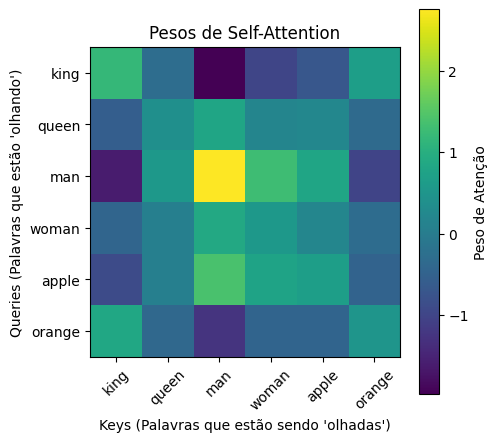

Matriz de Pesos de Atenção (Linha = Query, Coluna = Key):
[[ 1.184 -0.289 -1.971 -0.989 -0.696  0.686]
 [-0.566  0.376  0.807  0.182  0.215 -0.331]
 [-1.614  0.558  2.756  1.296  0.814 -0.998]
 [-0.424  0.076  0.888  0.541  0.202 -0.303]
 [-0.887  0.068  1.397  0.766  0.676 -0.474]
 [ 0.839 -0.379 -1.264 -0.453 -0.442  0.495]]


In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(5,5))
plt.imshow(scores, cmap='viridis')
plt.xticks(ticks=np.arange(len(vocab)), labels=vocab, rotation=45)
plt.yticks(ticks=np.arange(len(vocab)), labels=vocab)
plt.xlabel("Keys (Palavras que estão sendo 'olhadas')")
plt.ylabel("Queries (Palavras que estão 'olhando')")
plt.title("Pesos de Self-Attention")
plt.colorbar(label='Peso de Atenção')
plt.show()

print("Matriz de Pesos de Atenção (Linha = Query, Coluna = Key):")
print(scores.round(3))

Note que cada elemento $s_{ij}$ é o produto escalar (dot product) entre:

* o vetor **query** do token $i$
* e o vetor **key** do token $j$

$$ s_{ij} = \sum^D_{d=1} Q_{i,d}K_{j,d}$$

que é **exatamente uma medida similaridade** (de alinhamento) entre dois vetores no espaço de embeddings!

* $Q_{i}K_{j}$ alinhados $s_{ij}$ é positivo e alto (*alta atenção*)
* $Q_{i}K_{j}$ ortogonais $s_{ij}$ é zero (*baixa atenção*)
* $Q_{i}K_{j}$ ortogonais $s_{ij}$ é negativo (*atenção mínima*)


Então, **o mecanismo de atenção mede quão similares são as representações internas de dois tokens**, do ponto de vista da query e da key.

<br>

---

> **A matriz de atenção é, em essência, uma matriz de correlação entre tokens, aprendida dinamicamente.**


# Obtendo uma matriz de atenção real

In [ ]:
from transformers import TFBertModel, BertTokenizer
import tensorflow as tf

# Carregar o tokenizer e o modelo BERT pré-treinado
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
# Tentar carregar os pesos do PyTorch e converter para TensorFlow
model = TFBertModel.from_pretrained('bert-base-uncased', from_pt=True)

print("Tokenizer e modelo BERT carregados com sucesso!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.bias', 'cls.predictions.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Al

Tokenizer e modelo BERT carregados com sucesso!


In [ ]:
# sentence = ''.join([f"{word} " for word in vocab])
# print(sentence)
sentence = "The cat climbed onto the roof and meowed"

# Tokenizar as frases
inputs = tokenizer(sentence, return_tensors="tf", padding=True, truncation=True)

print(f"Tokens: {tokenizer.convert_ids_to_tokens(inputs['input_ids'][0].numpy())}")


Tokens: ['[CLS]', 'the', 'cat', 'climbed', 'onto', 'the', 'roof', 'and', 'me', '##owed', '[SEP]']


Obtendo as camadas de atenção com `output_attentions=True`.  



In [ ]:
#@markdown TensorFlow SelfAttention class (just run)
import tensorflow as tf
import numpy as np

# 1. Definir a camada de Self-Attention
class SelfAttention(tf.keras.layers.Layer):
    def __init__(self, d_model):
        super(SelfAttention, self).__init__()
        self.d_model = d_model
        # Camadas lineares para projetar a entrada em Q, K e V
        self.wq = tf.keras.layers.Dense(d_model)
        self.wk = tf.keras.layers.Dense(d_model)
        self.wv = tf.keras.layers.Dense(d_model)

    def call(self, x):
        # x é a entrada (batch_size, seq_len, d_model)

        # 1. Projeção em Q, K, V
        q = self.wq(x)  # (batch_size, seq_len, d_model)
        k = self.wk(x)  # (batch_size, seq_len, d_model)
        v = self.wv(x)  # (batch_size, seq_len, d_model)

        # 2. Cálculo da Pontuação de Atenção (Q * K^T)
        # Transpõe K para (batch_size, d_model, seq_len)
        matmul_qk = tf.matmul(q, k, transpose_b=True)  # (batch_size, seq_len, seq_len)

        # 3. Escalonamento (Scaled Dot-Product Attention)
        dk = tf.cast(tf.shape(k)[-1], tf.float32)
        scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)

        # 4. Softmax para obter os Pesos de Atenção
        attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)  # (batch_size, seq_len, seq_len)

        # 5. Ponderação dos Valores (Attention Weights * V)
        output = tf.matmul(attention_weights, v)  # (batch_size, seq_len, d_model)

        return output, attention_weights

In [ ]:
# Obter embeddings usando o modelo BERT e os pesos de atenção internos
# O output[0] geralmente contém a última camada oculta (last_hidden_state)
outputs_with_attn = model(inputs, output_attentions=True)
embeddings = outputs_with_attn.last_hidden_state
attention_weights_bert = outputs_with_attn.attentions

print(f"Embeddings da Frase (Formato): {embeddings.shape}")
print(f"Pesos de Atenção Internos do BERT (Frase - Camadas, Heads, SeqLen, SeqLen): {attention_weights_bert[0].shape}")

# Instanciar a camada de Self-Attention com a dimensão do modelo BERT (768)
# A classe SelfAttention já foi definida em uma célula anterior.
attention_layer_bert = SelfAttention(d_model=embeddings.shape[-1])

# Calcular os pesos de atenção para cada frase usando a camada SelfAttention simplificada
# A camada retorna a saída contextualizada e os pesos de atenção
_, weights = attention_layer_bert(embeddings)

print(f"\nPesos de Atenção da Frase (Camada SelfAttention Simplificada - Formato): {weights.shape}")


Embeddings da Frase (Formato): (1, 11, 768)
Pesos de Atenção Internos do BERT (Frase - Camadas, Heads, SeqLen, SeqLen): (1, 12, 11, 11)

Pesos de Atenção da Frase (Camada SelfAttention Simplificada - Formato): (1, 11, 11)


## Visualizar a matriz de atenção

Aqui, vamos excluir os tokens de início e fim para simplificar.

Com múltiplas camadas, o modelo constrói representações hierárquicas:

| Camada | Nível de abstração        | Exemplo de informação aprendida       |
| :----- | :------------------------ | :------------------------------------ |
| 1-3    | Estruturas locais         | sintaxe, morfologia, concordância     |
| 4-6    | Relações de médio alcance | sujeito-verbo, adjuntos, dependências |
| 7-9    | Relações de longo alcance | co-referências, tópicos               |
| 10-12  | Semântica global e estilo | intenção, coerência, continuidade     |




In [ ]:
attention_weights_bert[0][0,0,:,:].shape

TensorShape([11, 11])

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_attention_matrix(attention_weights_bert, inputs, layer=0):

  # Visualizar a matriz de atenção da Frase 1 (usando a camada SelfAttention simplificada)
  weights = attention_weights_bert[0][0,layer,:,:]
  attention_matrix = weights.numpy() # Pega a matriz de atenção para a primeira (e única) sequência

  # Simplificada
  attention_matrix = attention_matrix[1:-1, 1:-1]

  plt.figure(figsize=(5,5))
  plt.imshow(attention_matrix, cmap='viridis')

  # Obter os tokens da frase 1 para os rótulos
  tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0].numpy())
  tokens = tokens[1:-1]
  seq_len = len(tokens)

  plt.xticks(ticks=np.arange(seq_len), labels=tokens, rotation=90)
  plt.yticks(ticks=np.arange(seq_len), labels=tokens)
  plt.xlabel("Keys (Tokens que estão sendo 'olhados')")
  plt.ylabel("Queries (Tokens que estão 'olhando')")
  plt.title("Pesos de Self-Attention (Frase - Simplificado)")
  plt.colorbar(label='Peso de Atenção')
  plt.tight_layout() # Ajusta o layout para evitar sobreposição
  plt.show()

  # print("Matriz de Pesos de Atenção (Frase - Simplificado - Linha = Query, Coluna = Key):")
  # print(attention_matrix.round(3))

  return



Camada local de concordância...


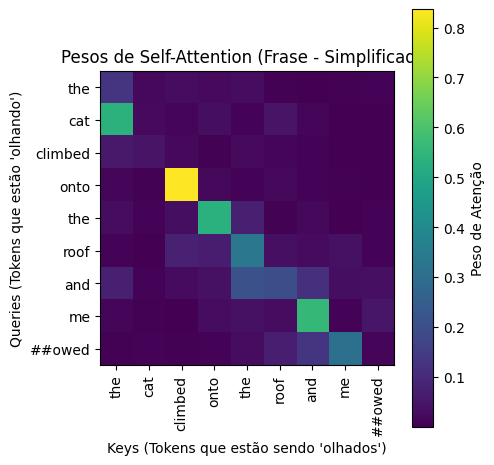

In [ ]:
print('Camada local de concordância...')
plot_attention_matrix(attention_weights_bert, inputs, 2)

Camada: sujeito-verbo, adjuntos, dependências...


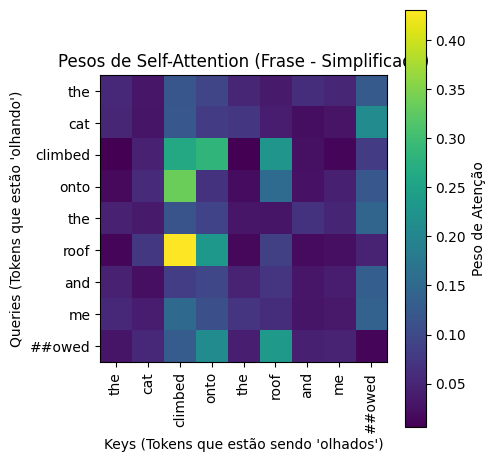

In [ ]:
print('Camada: sujeito-verbo, adjuntos, dependências...')
plot_attention_matrix(attention_weights_bert, inputs, 5)

Camada: co-referências, tópicos...


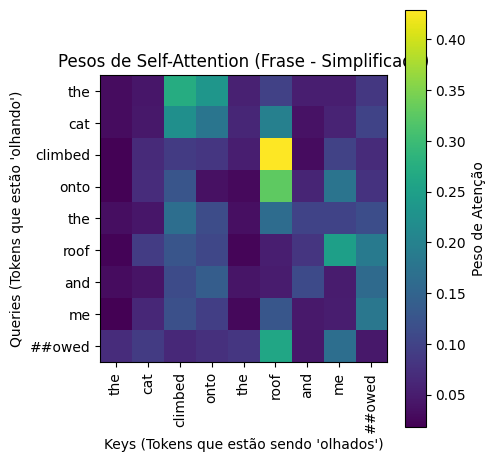

In [ ]:
print('Camada: co-referências, tópicos...')
plot_attention_matrix(attention_weights_bert, inputs, 8)

Camada: intenção, coerência, continuidade...


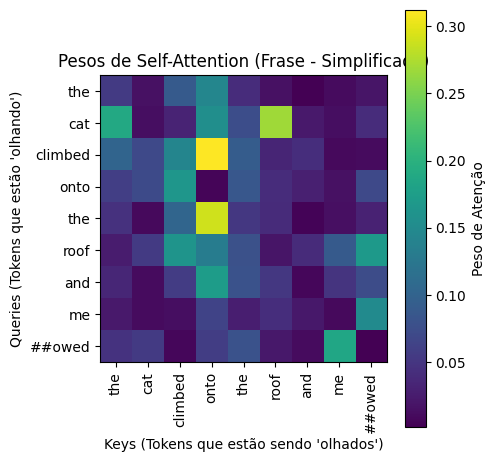

In [ ]:
print('Camada: intenção, coerência, continuidade...')
plot_attention_matrix(attention_weights_bert, inputs, 11)

# Múltiplas cabeças de leitura

Uma das partes mais importantes dos transformes ainda é sua capacidade de processamento paralelo (diferentemente de redes neurais recorrentes, como as LSTM) o que permite o treinamento de grandes quantidades de dados simultaneamente. Mas fica uma pergunta:  


> **Como múltiplas cabeças de atenção podem operar em paralelo, se o modelo é uma única rede (um conjunto de pesos compartilhado)? Como evitae "conflitos" entre as cabeças?**



Se temos, por exemplo, 12 (GPT-2) cabeças de atenção, então o modelo contém:

$$ W_Q^{(1)}, W_K^{(1)}, W_V^{(1)},..., W_Q^{(12)}, W_K^{(12)}, W_V^{(12)}$$

Mas cada cabeça trabalha em um subespaço de 768/21 = 64 dimensões para, no fim, as saídas (todas de 64 dimensões) serem concatenadas (12 x 64 = 768) e  projetadas de volta para o espaço original. Sendo matrizes independentes, elas podem ser treinadas independemente uma das outras, e em paralelo.


In [ ]:
%%script echo off
Entrada: X  (shape: [tokens, 768])

      ┌────────────────────────────┐
      │ Cabeça 1: Q1, K1, V1 (64d) │──┐
      ├────────────────────────────┤  │
      │ Cabeça 2: Q2, K2, V2 (64d) │──┤
      ├────────────────────────────┤  │  (12 cabeças paralelas)
      │ Cabeça ...                 │  │
      ├────────────────────────────┤  │
      │ Cabeça 12: Q12, K12, V12   │──┘
      └────────────────────────────┘

Concatenação → Linear Projection → Saída (768d)



<br>

![imagem](https://github.com/Rogerio-mack/Modelos_de_Linguagem_e_Generativos/blob/main/figures/Attention_3.png?raw=true)

A única parte compartilhada é:

* A entrada $X$, todas as cabeças partem dos mesmos embeddings (*não são camadas!*)
* E o gradiente final, que retropropaga erro a todas as cabeças



## Camadas $\times$ Cabeças de Atenção

As camadas são o que fornecem os diferentes níveis de abstração, e um erro comum é confundir as camadas com as cabeças de atenção. As camadas, são sequenciais, diferentemente das cabeças de atenção, não podem ser paralelizadas. No GPT-12, existem 12 cabeças de atenção, mas também 12 camadas!



In [ ]:
%%script echo off

Entrada (embeddings)
  ↓
Camada 1 (12 cabeças de atenção + feed-forward)
  ↓
Camada 2 (12 cabeças de atenção + feed-forward)
  ↓
...
  ↓
Camada 12
  ↓
Saída final (para previsão do próximo token)


Token embeddings
   │
   ├─ Camada 1 ─┬─ Cabeça 1
   │             ├─ Cabeça 2
   │             └─ ...
   │             ↓ (concat + projeção)
   │          Feed-Forward + Norm
   │
   ├─ Camada 2 ─┬─ Cabeça 1
   │             ├─ Cabeça 2
   │             └─ ...
   │
   └─ ... até Camada 12




off
